<a href="https://colab.research.google.com/github/trajashree/deep-learning/blob/main/neural_network_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Neural Network with 3 Inputs, 2 Hidden Layers, and 1 Output

This notebook demonstrates:
- Creating a simulated dataset with 3 input features and 1 output.  
- Building a simple neural network with:
  - **3 input nodes**
  - **2 hidden layers (2 nodes each)**
  - **1 output node**
- Training and making predictions.


In [21]:
# Import NumPy for numerical computations and array operations
import numpy as np

# Import Pandas for loading and manipulating datasets
import pandas as pd

# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler to normalize/standardize feature values
from sklearn.preprocessing import StandardScaler

# Import TensorFlow itself, typically as tf
import tensorflow as tf

# Import Sequential model to build a neural network layer by layer
from tensorflow.keras.models import Sequential

# Import Dense and Input layers to create fully connected neural network layers and define input shape
from tensorflow.keras.layers import Dense, Input

# Import Matplotlib for plotting graphs and visualizing results
import matplotlib.pyplot as plt

In [25]:
import numpy as np

# Set a random seed so that the same random numbers are generated every time
np.random.seed(42)

# Define the total number of samples (data points)
n_samples = 200

# Generate a dataset with 200 samples and 3 input features
# Each feature value is a random number between 0 and 1
X = np.random.rand(n_samples, 3)

# Generate the target (output) values
# Weighted sum of the three features:
# Feature 1 -> 30% contribution
# Feature 2 -> 50% contribution
# Feature 3 -> 20% contribution
# Add small random noise to make the data more realistic
# If the final value is greater than 0.5, assign class True; otherwise False
y = (X[:,0]*0.3 + X[:,1]*0.5 + X[:,2]*0.2 +
     np.random.normal(0, 0.05, n_samples)) > 0.5

# Convert Boolean values (True/False) into integers (1/0)
y = y.astype(int)

# Display the dimensions of the input feature matrix
print("Input shape:", X.shape)

# Display the dimensions of the output vector
print("Output shape:", y.shape)

Input shape: (200, 3)
Output shape: (200,)


In [ ]:
# Split the dataset into training and testing sets
# 80% of the data is used for training and 20% for testing
# random_state=42 ensures the same split every time the code is executed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create an object of StandardScaler to standardize the feature values
scaler = StandardScaler()

# Compute the mean and standard deviation from the training data
# Then transform the training data so that each feature has:
# Mean = 0 and Standard Deviation = 1
X_train = scaler.fit_transform(X_train)

# Use the same mean and standard deviation obtained from the training data
# to standardize the test data
X_test = scaler.transform(X_test)

In [26]:
tf.keras.backend.clear_session()

# Build a Sequential Neural Network
# The layers are added one after another
model = Sequential([
    # Explicit Input Layer to define the input shape
    Input(shape=(3,)),

    # First Hidden Layer
    # Dense(2) -> 2 neurons in this hidden layer
    # activation='relu' -> Uses the ReLU activation function
    Dense(2, activation='relu'),

    # Second Hidden Layer
    # Dense(2) -> 2 neurons
    # activation='relu' -> Applies the ReLU activation function
    Dense(2, activation='relu'),

    # Output Layer
    # Dense(1) -> One output neuron for binary classification
    # activation='sigmoid' -> Sigmoid activation function for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the neural network
# optimizer='adam' -> Adam optimizer updates the weights efficiently
# loss='binary_crossentropy' -> Loss function for binary classification
# metrics=['accuracy'] -> Display classification accuracy during training
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the architecture of the neural network
# It shows the layers, output shapes, and number of trainable parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

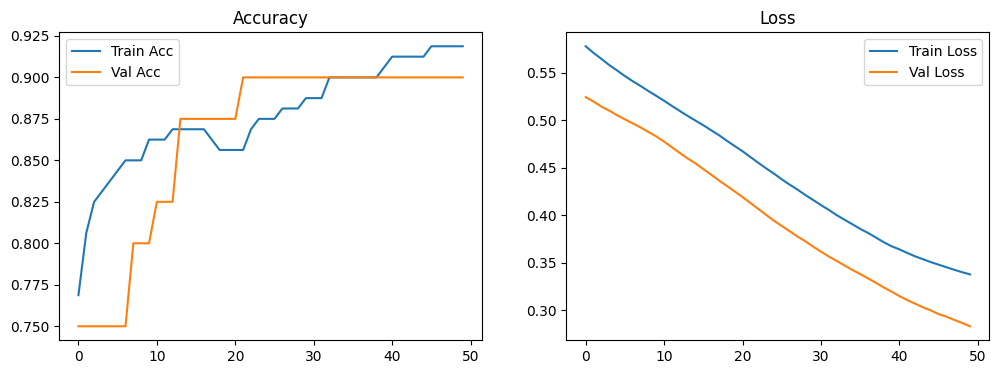

In [23]:

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0, validation_data=(X_test, y_test))

# Plot accuracy and loss
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [24]:

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Sample Predictions:")
print("True labels:     ", y_test[:10])
print("Predicted labels:", y_pred[:10].ravel())


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Sample Predictions:
True labels:      [0 0 1 1 1 0 0 1 1 0]
Predicted labels: [0 0 1 1 1 0 0 1 1 1]
